# Week 1 — Minecraft Knowledge Agent

**도메인**: 마인크래프트 지식 에이전트  
**목표**: StateGraph로 직접 ReAct 루프를 구성하고, 도메인 도구 3개를 활용하여 구조화된 응답 반환

## 그래프 구조
```
START → agent → should_continue() → tools → agent (루프)
                                  → format_output → END
```
- **agent**: LLM이 도구 호출 여부를 직접 판단
- **tools**: ToolNode가 실제 도구 실행 (오류 처리 포함)
- **format_output**: 대화 기록 → Pydantic 구조화 응답
- **조건부 엣지**: `tool_calls` 유무로 tools / format_output 분기

In [1]:
import sys
import os


sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
os.environ['LANGSMITH_TRACING'] = 'false'
os.environ['LANGSMITH_TRACING_V2'] = 'false'

## 1. 그래프 로드 및 시각화

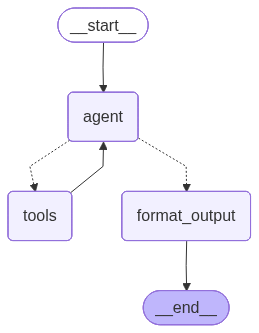

In [2]:
from graph import graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 2. 헬퍼 함수 정의

In [3]:
from langchain_core.messages import HumanMessage
from schema import MinecraftAgentResponse


def run_agent(question: str) -> None:
    result = graph.invoke(
        {'messages': [HumanMessage(content=question)], 'structured_output': None},
        config={'recursion_limit': 15},
    )
    resp = result.get('structured_output')
    if resp:
        tools = ', '.join(resp.tools_used) if resp.tools_used else '없음'
        print(f'Q: {question}')
        print(f'A: {resp.answer}')
        print(f'   (사용 도구: {tools} | 신뢰도: {resp.confidence:.0%})')


print('헬퍼 함수 정의 완료')

헬퍼 함수 정의 완료


## 3. 테스트 질문

In [4]:
run_agent('다이아몬드 검을 만들려면 재료가 뭐야? 레시피랑 같이 알려줘.')

Q: 다이아몬드 검을 만들려면 재료가 뭐야? 레시피랑 같이 알려줘.
A: 다이아몬드 검을 만들기 위해 필요한 재료는 다이아몬드 2개와 나무 막대기 1개입니다. 제작 레시피는 다음과 같습니다:

- 첫 번째 줄: 다이아몬드
- 두 번째 줄: 다이아몬드
- 세 번째 줄: 나무 막대기

이렇게 배치하여 인벤토리에서 제작하면 다이아몬드 검 1개가 완성됩니다. 제작 테이블이 필요하지 않으며, 인벤토리에서 직접 만들 수 있습니다.
   (사용 도구: get_crafting_recipe | 신뢰도: 90%)


In [5]:
run_agent('크리퍼를 안전하게 처치하는 방법을 알려줘. 약점이 뭐야?')

Q: 크리퍼를 안전하게 처치하는 방법을 알려줘. 약점이 뭐야?
A: 크리퍼는 다소 위험한 적대적 몹으로, 안전하게 처치하려면 몇 가지 방법이 있습니다. 1. **원거리 공격**: 활이나 다른 원거리 무기를 사용하여 크리퍼를 멀리서 처치하는 것이 좋습니다. 이렇게 하면 폭발 위험을 피할 수 있습니다. 2. **근접 전투**: 크리퍼에 접근해 검으로 한 번 공격한 후, 즉시 2~3칸 후퇴하는 방법이 효과적입니다. 크리퍼는 공격 후 1.5초 카운트다운을 거치고 폭발합니다. 이 타이밍을 이용해 반복적으로 공격하고 물러나세요. 3. **고양이 이용**: 크리퍼는 고양이를 무서워하므로, 고양이를 집에 두면 크리퍼가 근처에 접근하지 않도록 할 수 있습니다. 4. **충전된 크리퍼 주의**: 번개에 맞아 충전된 크리퍼는 특히 강한 폭발력을 지니고 있으니 조심해야 합니다. 크리퍼의 약점은 원거리 화살 공격, 검으로 때린 직후 빠르게 후퇴하는 행동이며, 적절한 전략을 사용하면 안전하게 처치할 수 있습니다.
   (사용 도구: get_mob_info | 신뢰도: 90%)


In [6]:
run_agent('엔더 드래곤을 처치하기 위한 준비물과 전략을 알려줘. 눈물의 도가니는 어떻게 만들어?')
# 여러 도구를 사용해서 답변해야하는 질문 

Q: 엔더 드래곤을 처치하기 위한 준비물과 전략을 알려줘. 눈물의 도가니는 어떻게 만들어?
A: 엔더 드래곤을 처치하기 위한 전략과 준비물, 그리고 눈물의 도가니 제작 방법을 안내해드리겠습니다.

**준비물:**
1. 다이아몬드 갑옷 (보호 인첸트 권장)
2. 다이아몬드 검 (날카로움 인첸트 권장)
3. 활 + 화살 64개 이상 (무한 인첸트 활이면 화살 최소 1개로 충분)
4. 황금 사과 5개 이상
5. 음식 (예: 스테이크)
6. 눈덩이 (엔드 크리스탈 파괴용)

**전투 전략:**
1. 먼저 모든 흑요석 기둥에 있는 엔드 크리스탈을 파괴합니다. 활 또는 눈덩이를 사용하세요. 철창 케이지 안의 크리스탈은 기둥 위로 올라가서 직접 파괴해야 합니다.
2. 크리스탈이 폭발할 경우 반경 4블록 안에 있으면 즉사할 수 있으므로 반드시 원거리에서 파괴하세요.
3. 엔더 드래곤이 중앙 제단에 착지하면 검으로 머리를 공격할 수 있는데, 이때 데미지가 2배로 증가합니다.
4. 드래곤의 용 브레스 공격 뒤에 생성되는 보라색 구름에 절대로 서 있지 마세요.
5. 엔드 스톤 기둥 위에 올라가 높이를 유지하면 드래곤의 접근이 줄어듭니다.

**눈물의 도가니 제작 방법:**
눈물의 도가니는 블레이즈 파우더 1개와 엔더 진주 1개로 만들 수 있으며, 인벤토리에서 바로 제작 가능합니다. 제작 패턴은 다음과 같습니다:
- 블레이즈 파우더를 상단에 놓고,
- 그 아래에 엔더 진주를 배치합니다.

눈물의 도가니는 엔드 포탈을 활성화하는 데 12개가 필요합니다. 이제 준비물을 잘 갖추고 전략적으로 엔더 드래곤을 처치해 보세요!
   (사용 도구: get_mob_info, get_crafting_recipe | 신뢰도: 95%)


In [7]:
run_agent('인첸팅 테이블을 만들고 싶어. 필요한 재료와 주의사항을 알려줘.')

Q: 인첸팅 테이블을 만들고 싶어. 필요한 재료와 주의사항을 알려줘.
A: 인첸팅 테이블을 만들기 위해서는 다음과 같은 재료가 필요합니다:

- 다이아몬드 2개
- 흑요석 4개
- 책 1개

제작 패턴은 다음과 같습니다:

- 첫 번째 줄: 빈칸, 책, 빈칸
- 두 번째 줄: 다이아몬드, 흑요석, 다이아몬드
- 세 번째 줄: 흑요석, 흑요석, 흑요석

인첸팅 테이블을 만들 때 주변에 책장을 15개 배치하면 최대 레벨 30의 인첸트가 가능하니, 이 점도 유의하세요. 제작 테이블에서 이 재료들을 조합하면 인첸팅 테이블을 얻을 수 있습니다.
   (사용 도구: get_crafting_recipe | 신뢰도: 95%)


In [8]:
run_agent('마인크래프트에서 서바이벌 초반에 가장 먼저 해야 할 일이 뭐야?') 
# 도구없이도 답변할 수 있는 질문

Q: 마인크래프트에서 서바이벌 초반에 가장 먼저 해야 할 일이 뭐야?
A: 마인크래프트 서바이벌 모드의 초반에는 다음과 같은 일들이 중요합니다:

1. **목재 수확**: 나무를 베어 목재를 확보하세요. 목재는 기본적인 도구와 건축 재료로 필요합니다.

2. **도구 제작**: 목재를 사용해 작업대를 만들고, 기본 도구(삽, 곡괭이, 도끼)를 만드세요. 도구는 자원을 더 효율적으로 채취하는 데 도움이 됩니다.

3. **식량 확보**: 주변에서 동물을 사냥하거나 식물을 수확해 식량을 확보하세요. 건강과 허기를 유지하는 데 필수적입니다.

4. **대피소 건설**: 밤이 되면 적대적인 몹이 등장하므로 안전한 곳을 마련해 대피소를 만들어야 합니다. 간단하게 흙이나 나무로 벽을 세우거나 땅속에 공략할 수도 있습니다.

5. **불 피우기**: 석탄이나 나무를 활용해 횃불을 만들어 어두운 곳을 밝히고, 몹의 출현을 줄이세요. 불은 또한 요리와 광물 채굴에도 유용합니다.

이 단계를 통해 안전하게 초반을 넘어가고, 자원을 효율적으로 활용할 수 있습니다.
   (사용 도구: 없음 | 신뢰도: 90%)


## 4. 그래프 노드/엣지 구조 확인

In [9]:
g = graph.get_graph()

print('노드 목록:')
for node in g.nodes:
    print(f'  - {node}')

print('\n엣지 목록:')
for edge in g.edges:
    cond = f' (조건: {edge.data})' if edge.data else ''
    print(f'  {edge.source} → {edge.target}{cond}')

노드 목록:
  - __start__
  - agent
  - tools
  - format_output
  - __end__

엣지 목록:
  __start__ → agent
  agent → format_output
  agent → tools
  tools → agent
  format_output → __end__
